# Netflix Movies and TV Shows Analysis

**Dataset:** Netflix Movies and TV Shows  
**Source:** [Kaggle - Netflix Shows](https://www.kaggle.com/datasets/shivamb/netflix-shows)  
**Records:** 8,800+ titles  
**Attributes:** 12 columns

---

## Analytical Questions

**Question 1:** How has Netflix's content library grown from 2008 to 2021, and what patterns in content type (Movies vs TV Shows) and release timing reveal their strategic priorities?

**Question 2:** How does Netflix's content distribution vary across major producing countries, and what regional differences exist in content type ratios and genre preferences?

---

## 1. Setup and Data Loading

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Netflix Brand Colors
NETFLIX_RED = '#E50914'
NETFLIX_BLACK = '#221f1f'
NETFLIX_GREY = '#564d4d'
NETFLIX_WHITE = '#f5f5f1'

# Set Style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Load Dataset
df = pd.read_csv('/content/netflix_titles.csv')

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")

Dataset Shape: 8807 rows, 12 columns

Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [ ]:
# Preview Data
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 2. Data Cleaning and Preparation

In [ ]:
# Check Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    'Missing %': missing_pct.values
})
missing_df[missing_df['Missing Count'] > 0]

,Column,Missing Count,Missing %
3,director,2634,29.91
4,cast,825,9.37
5,country,831,9.44
6,date_added,10,0.11
8,rating,4,0.05
9,duration,3,0.03


In [ ]:
# Data Cleaning
# Fill missing countries with mode
df['country'] = df['country'].fillna(df['country'].mode()[0])

# Fill missing director and cast
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')

# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Drop rows with missing date_added
df = df.dropna(subset=['date_added'])

# Feature Engineering
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['month_name'] = df['date_added'].dt.month_name()

# Extract primary country (first country listed)
df['primary_country'] = df['country'].apply(lambda x: x.split(',')[0].strip())

# Extract primary genre
df['primary_genre'] = df['listed_in'].apply(lambda x: x.split(',')[0].strip())

print(f"Cleaned Dataset: {df.shape[0]} rows")
print("\nNew features created: year_added, month_added, month_name, primary_country, primary_genre")

Cleaned Dataset: 8709 rows

New features created: year_added, month_added, month_name, primary_country, primary_genre


In [ ]:
# Dataset Overview After Cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8709 entries, 0 to 8806
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   show_id          8709 non-null   object        
 1   type             8709 non-null   object        
 2   title            8709 non-null   object        
 3   director         8709 non-null   object        
 4   cast             8709 non-null   object        
 5   country          8709 non-null   object        
 6   date_added       8709 non-null   datetime64[ns]
 7   release_year     8709 non-null   int64         
 8   rating           8705 non-null   object        
 9   duration         8706 non-null   object        
 10  listed_in        8709 non-null   object        
 11  description      8709 non-null   object        
 12  year_added       8709 non-null   int32         
 13  month_added      8709 non-null   int32         
 14  month_name       8709 non-null   object      

## 3. Basic Content Overview

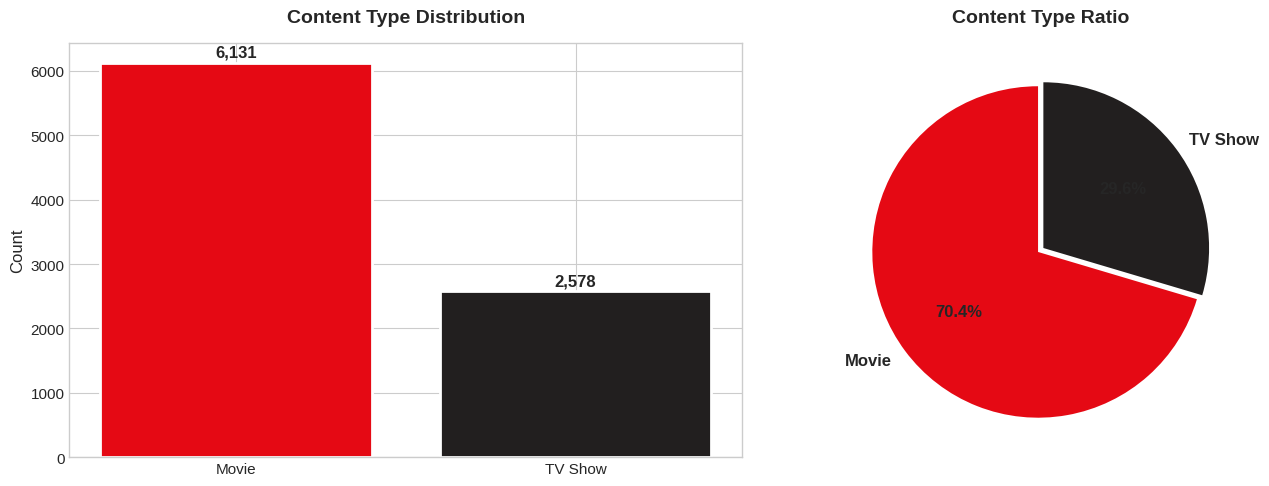

In [ ]:
# Content Type Distribution
type_counts = df['type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar Chart
bars = axes[0].bar(type_counts.index, type_counts.values,
                   color=[NETFLIX_RED, NETFLIX_BLACK],
                   edgecolor='white', linewidth=2)
axes[0].set_title('Content Type Distribution', fontweight='bold', pad=15)
axes[0].set_ylabel('Count')
axes[0].set_xlabel('')

# Add value labels
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 50,
                 f'{int(height):,}', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Pie Chart
axes[1].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
            colors=[NETFLIX_RED, NETFLIX_BLACK], startangle=90,
            explode=[0.02, 0.02], textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Content Type Ratio', fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

**Observation:** Netflix's library is dominated by Movies (~70%), with TV Shows making up the remaining ~30%. This suggests Netflix's initial strategy focused heavily on licensing movies before shifting towards original TV content.

---

# Question 1: Temporal Content Strategy

**How has Netflix's content library grown from 2008 to 2021, and what patterns in content type (Movies vs TV Shows) and release timing reveal their strategic priorities?**

---

### 1.1 Content Growth Over Years

In [ ]:
# Content added per year by type
yearly_content = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
yearly_content['Total'] = yearly_content.sum(axis=1)

# Display table
yearly_content

type,Movie,TV Show,Total
year_added,,,
2008,1,1,2
2009,2,0,2
2010,1,0,1
2011,13,0,13
2012,3,0,3
2013,6,4,10
2014,19,4,23
2015,56,17,73
2016,253,165,418


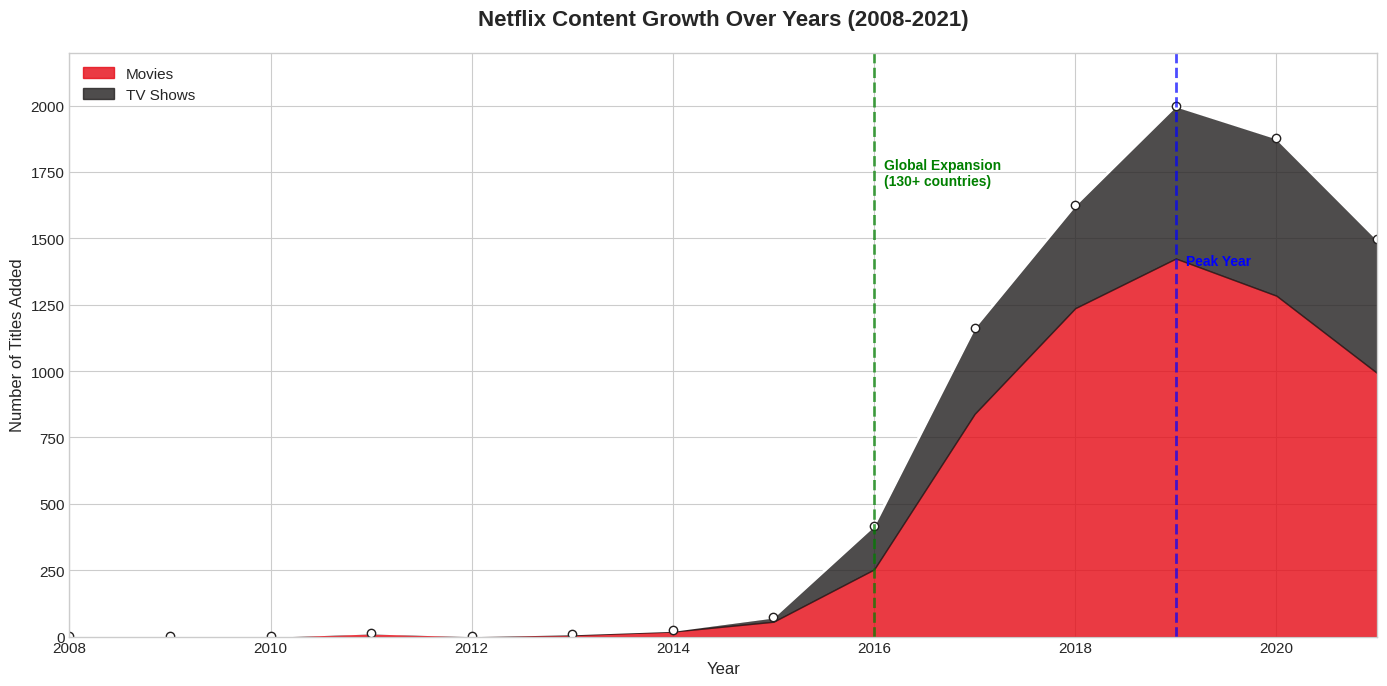

In [ ]:
# Visualization: Content Growth Over Years
fig, ax = plt.subplots(figsize=(14, 7))

x = yearly_content.index
width = 0.35

# Stacked Area Chart
ax.fill_between(x, 0, yearly_content['Movie'], alpha=0.8, color=NETFLIX_RED, label='Movies')
ax.fill_between(x, yearly_content['Movie'], yearly_content['Movie'] + yearly_content['TV Show'],
                alpha=0.8, color=NETFLIX_BLACK, label='TV Shows')

# Add markers for total
ax.plot(x, yearly_content['Total'], 'o-', color='white', markersize=6, linewidth=2, markeredgecolor=NETFLIX_BLACK)

# Styling
ax.set_title('Netflix Content Growth Over Years (2008-2021)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Titles Added', fontsize=12)
ax.legend(loc='upper left', fontsize=11)
ax.set_xlim(yearly_content.index.min(), yearly_content.index.max())
ax.set_ylim(0, yearly_content['Total'].max() * 1.1)

# Add annotation for key year
ax.axvline(x=2016, color='green', linestyle='--', linewidth=2, alpha=0.7)
ax.text(2016.1, yearly_content['Total'].max() * 0.85, 'Global Expansion\n(130+ countries)',
        fontsize=10, fontweight='bold', color='green')

ax.axvline(x=2019, color='blue', linestyle='--', linewidth=2, alpha=0.7)
ax.text(2019.1, yearly_content['Total'].max() * 0.7, 'Peak Year',
        fontsize=10, fontweight='bold', color='blue')

plt.tight_layout()
plt.show()

**Observation:**
- Netflix experienced **explosive growth** starting from 2015-2016, coinciding with their global expansion to 130+ countries.
- **2019 was the peak year** for content additions, with nearly 2,000 new titles added.
- Movies consistently dominated new additions, but TV Shows growth accelerated after 2016.
- The slight decline in 2020-2021 may be attributed to COVID-19 production delays.

### 1.2 Movies vs TV Shows Ratio Over Time

In [ ]:
# Calculate ratio over years
yearly_content['Movie_Pct'] = (yearly_content['Movie'] / yearly_content['Total'] * 100).round(1)
yearly_content['TV_Show_Pct'] = (yearly_content['TV Show'] / yearly_content['Total'] * 100).round(1)

# Filter years with significant data
yearly_ratio = yearly_content[yearly_content['Total'] > 50][['Movie_Pct', 'TV_Show_Pct']]
yearly_ratio

type,Movie_Pct,TV_Show_Pct
year_added,,
2015,76.7,23.3
2016,60.5,39.5
2017,72.1,27.9
2018,76.1,23.9
2019,71.2,28.8
2020,68.4,31.6
2021,66.3,33.7


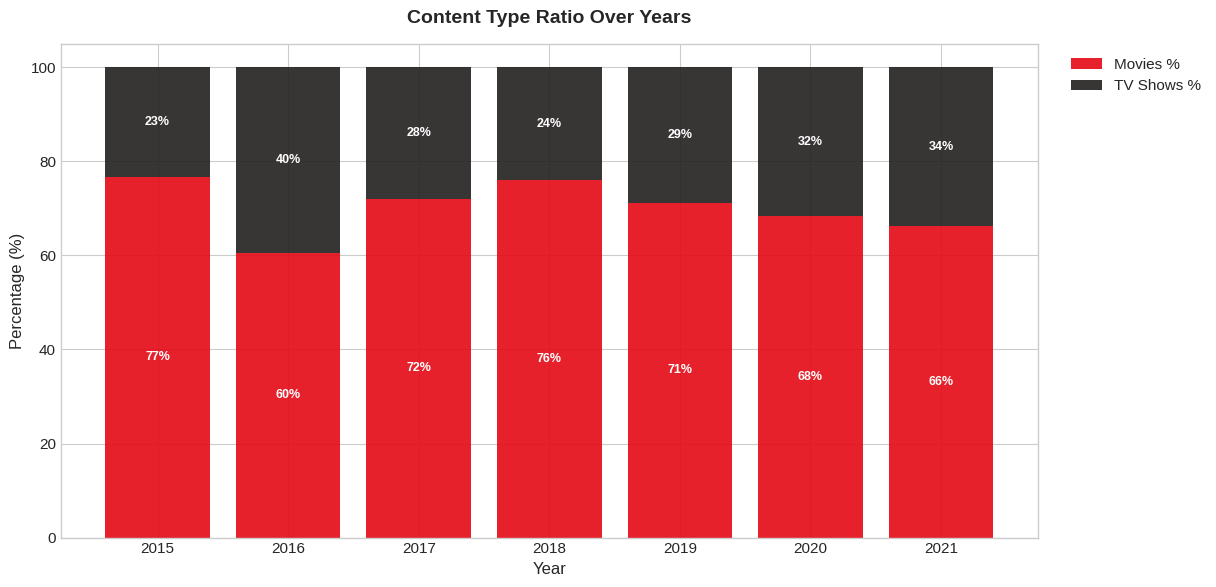

In [ ]:
# Visualization: Content Type Ratio Over Time
fig, ax = plt.subplots(figsize=(14, 6))

years = yearly_ratio.index

ax.bar(years, yearly_ratio['Movie_Pct'], color=NETFLIX_RED, label='Movies %', alpha=0.9)
ax.bar(years, yearly_ratio['TV_Show_Pct'], bottom=yearly_ratio['Movie_Pct'],
       color=NETFLIX_BLACK, label='TV Shows %', alpha=0.9)

for i, year in enumerate(years):
    movie_pct = yearly_ratio.loc[year, 'Movie_Pct']
    tv_pct = yearly_ratio.loc[year, 'TV_Show_Pct']
    ax.text(year, movie_pct/2, f'{movie_pct:.0f}%', ha='center', va='center',
            color='white', fontweight='bold', fontsize=9)
    ax.text(year, movie_pct + tv_pct/2, f'{tv_pct:.0f}%', ha='center', va='center',
            color='white', fontweight='bold', fontsize=9)

ax.set_title('Content Type Ratio Over Years', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Percentage (%)')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0))
ax.set_ylim(0, 105)

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

**Observation:**
- TV Shows percentage has been **steadily increasing** over the years, from ~20% to ~35%.
- This indicates Netflix's **strategic shift** towards original TV content to increase viewer engagement and retention.
- TV Shows drive binge-watching behavior, keeping subscribers on the platform longer.

### 1.3 Seasonal Patterns: When Does Netflix Add Content?

In [ ]:
# Monthly content additions
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_content = df.groupby('month_name').size().reindex(month_order)

# Create DataFrame for display
monthly_df = pd.DataFrame({
    'Month': month_order,
    'Content Added': monthly_content.values
})
monthly_df['Rank'] = monthly_df['Content Added'].rank(ascending=False).astype(int)
monthly_df

,Month,Content Added,Rank
0,January,727,8
1,February,557,12
2,March,734,7
3,April,759,4
4,May,626,11
5,June,724,9
6,July,819,1
7,August,749,6
8,September,765,3
9,October,755,5


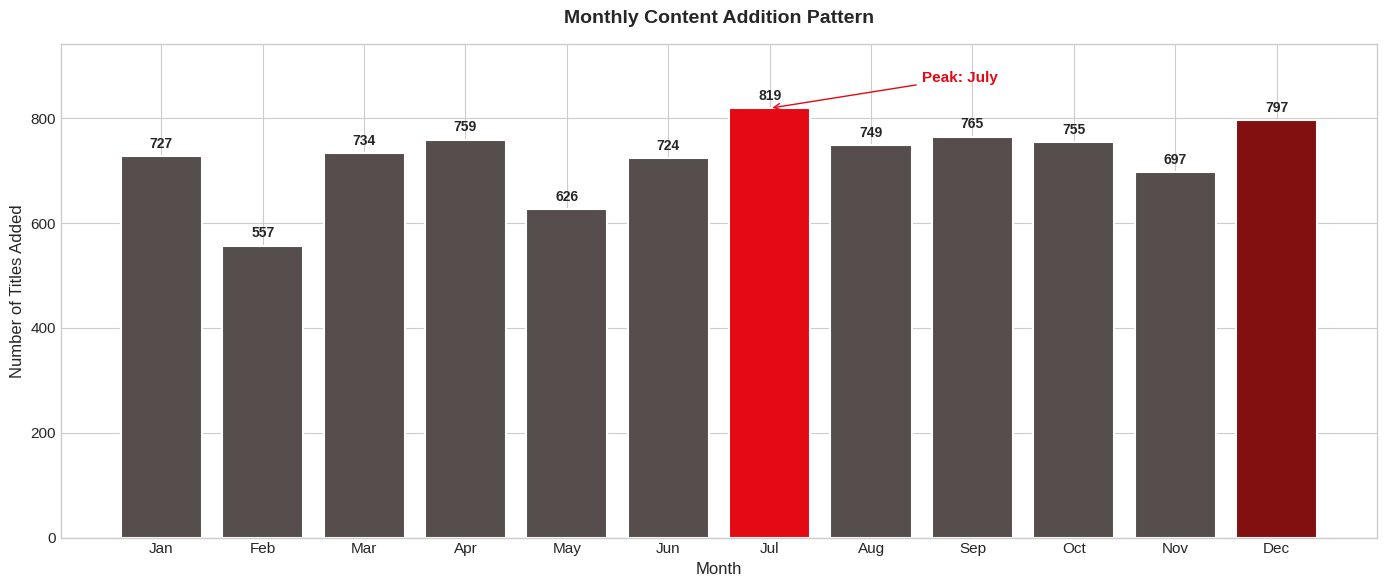

In [ ]:
# Visualization: Monthly Content Addition Pattern
fig, ax = plt.subplots(figsize=(14, 6))

months_short = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
colors = [NETFLIX_RED if v == monthly_content.max() else
          '#831010' if v == monthly_content.nlargest(2).iloc[-1] else
          NETFLIX_GREY for v in monthly_content.values]

bars = ax.bar(months_short, monthly_content.values, color=colors, edgecolor='white', linewidth=1.5)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Highlight peak months
peak_month = month_order[monthly_content.argmax()]
ax.annotate(f'Peak: {peak_month}', xy=(monthly_content.argmax(), monthly_content.max()),
            xytext=(monthly_content.argmax() + 1.5, monthly_content.max() + 50),
            fontsize=11, fontweight='bold', color=NETFLIX_RED,
            arrowprops=dict(arrowstyle='->', color=NETFLIX_RED))

ax.set_title('Monthly Content Addition Pattern', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Titles Added')
ax.set_ylim(0, monthly_content.max() * 1.15)

plt.tight_layout()
plt.show()

**Observation:**
- **July** and **December/January** are peak months for content additions.
- This aligns with **holiday seasons** (winter holidays, summer break) when viewership is highest.
- **February** shows the lowest content additions - shortest month with fewer holidays.
- Netflix strategically releases content when people have more leisure time.

### 1.4 Content Freshness: Release Year vs Year Added

In [ ]:
# Calculate content age (how old content was when added)
df['content_age'] = df['year_added'] - df['release_year']

# Average content age by year
freshness = df.groupby('year_added')['content_age'].mean().round(1)
freshness_df = pd.DataFrame({
    'Year': freshness.index,
    'Avg Content Age (Years)': freshness.values
})
freshness_df[freshness_df['Year'] >= 2015]

,Year,Avg Content Age (Years)
7,2015,1.3
8,2016,2.9
9,2017,3.9
10,2018,4.1
11,2019,5.3
12,2020,4.7
13,2021,5.8


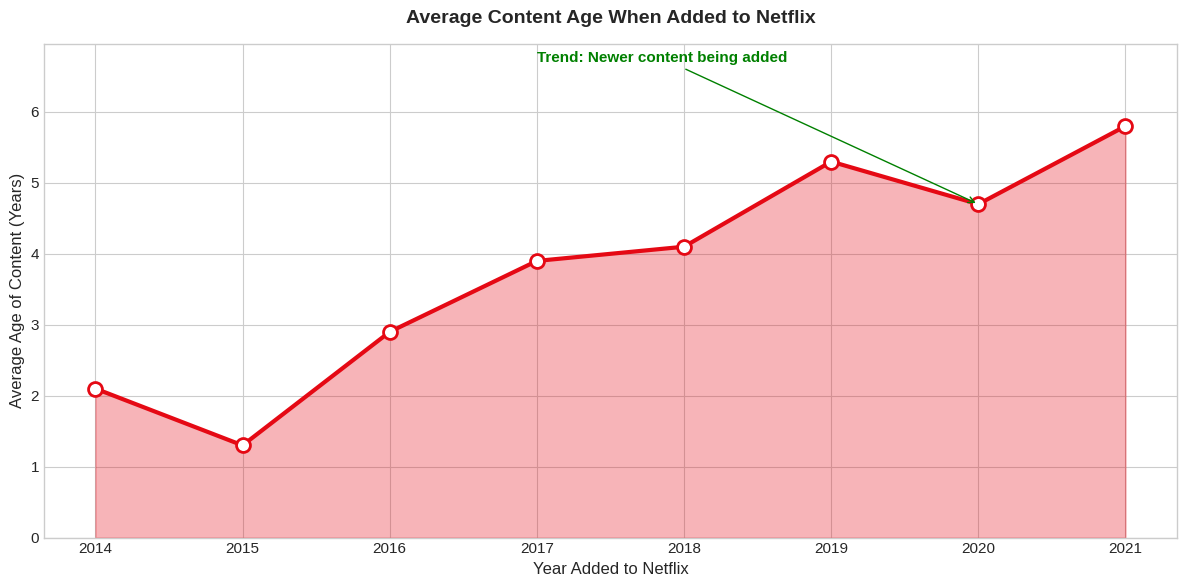

In [ ]:
# Visualization: Content Freshness Trend
fig, ax = plt.subplots(figsize=(12, 6))

fresh_data = freshness[freshness.index >= 2014]

ax.plot(fresh_data.index, fresh_data.values, 'o-', color=NETFLIX_RED,
        linewidth=3, markersize=10, markerfacecolor='white', markeredgewidth=2)
ax.fill_between(fresh_data.index, fresh_data.values, alpha=0.3, color=NETFLIX_RED)

ax.set_title('Average Content Age When Added to Netflix', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year Added to Netflix')
ax.set_ylabel('Average Age of Content (Years)')
ax.set_ylim(0, fresh_data.max() * 1.2)

# Add trend annotation
ax.annotate('Trend: Newer content being added',
            xy=(2020, fresh_data.loc[2020]),
            xytext=(2017, fresh_data.loc[2020] + 2),
            fontsize=11, fontweight='bold', color='green',
            arrowprops=dict(arrowstyle='->', color='green'))

plt.tight_layout()
plt.show()

**Observation:**
- Content age has increased over time, suggesting Netflix is adding more older/classic content alongside new originals.
- This reflects their shift from licensing older catalog content to **producing original content**.
- Newer content appeals more to younger demographics and maintains competitive advantage.

### Question 1 Summary

| Finding | Insight |
|---------|--------|
| Growth Pattern | Explosive growth from 2016 (global expansion), peak in 2019 |
| Content Mix | TV Shows percentage increasing (20% → 35%), strategic shift |
| Seasonality | Peak additions in July and December (holiday periods) |
| Content Age | Trend towards fresher content (more originals) |

---

# Question 2: Geographic Content Intelligence

**How does Netflix's content distribution vary across major producing countries, and what regional differences exist in content type ratios and genre preferences?**

---

### 2.1 Top Content Producing Countries

In [ ]:
# Top 15 countries by content count
country_counts = df['primary_country'].value_counts().head(15)

country_df = pd.DataFrame({
    'Country': country_counts.index,
    'Content Count': country_counts.values,
    'Percentage': (country_counts.values / len(df) * 100).round(1)
})
country_df

,Country,Content Count,Percentage
0,United States,3996,45.9
1,India,1007,11.6
2,United Kingdom,611,7.0
3,Canada,259,3.0
4,Japan,255,2.9
5,France,209,2.4
6,South Korea,206,2.4
7,Spain,177,2.0
8,Mexico,134,1.5
9,Australia,115,1.3


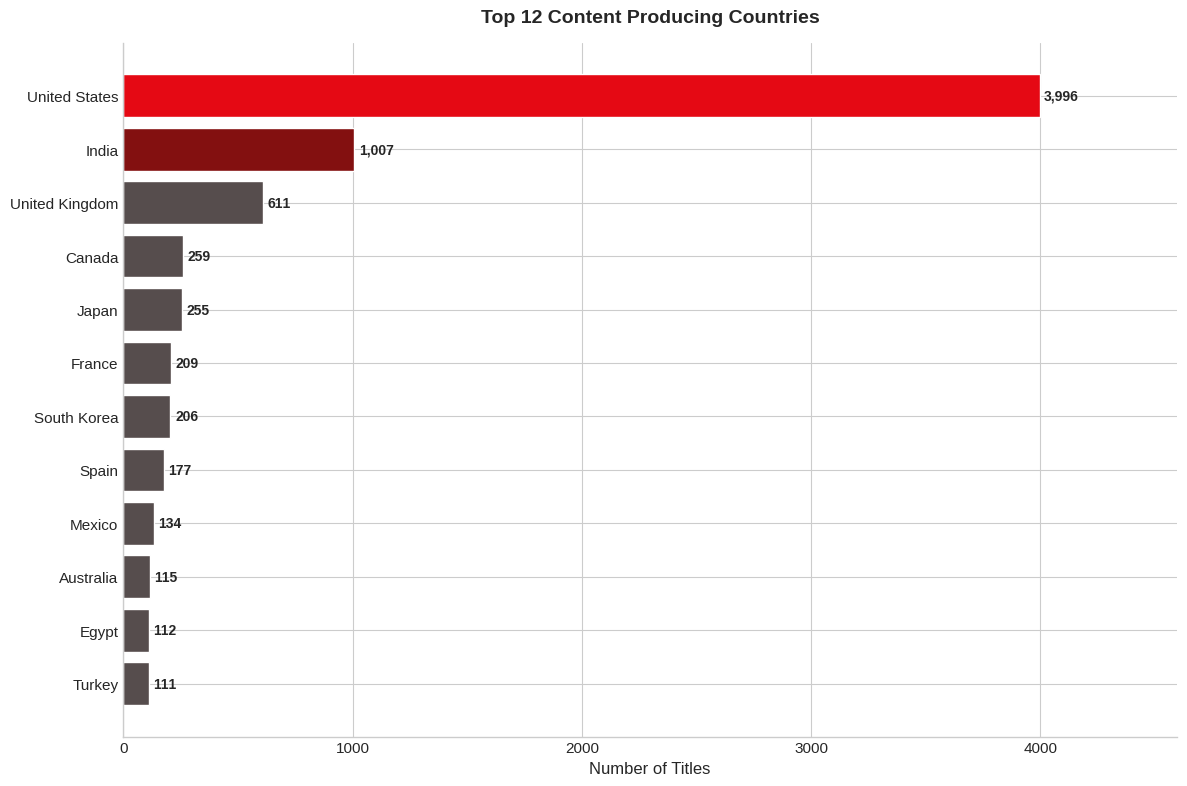

In [ ]:
# Visualization: Top Countries
fig, ax = plt.subplots(figsize=(12, 8))

top_countries = country_counts.head(12)
colors = [NETFLIX_RED if i == 0 else '#831010' if i == 1 else NETFLIX_GREY for i in range(len(top_countries))]

bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1], color=colors[::-1], edgecolor='white')

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + 20, bar.get_y() + bar.get_height()/2,
            f'{int(width):,}', ha='left', va='center', fontweight='bold', fontsize=10)

ax.set_title('Top 12 Content Producing Countries', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Titles')
ax.set_xlim(0, top_countries.max() * 1.15)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Observation:**
- **United States dominates** with ~40% of all content - Netflix's home market.
- **India** is second largest, reflecting Netflix's focus on the massive Indian market.
- Strong presence from **UK, Canada, France, Japan, South Korea** - all key international markets.
- Asian content (India, Japan, South Korea) represents a significant and growing portion.

### 2.2 Content Type by Country: Movies vs TV Shows

In [ ]:
# Content type ratio by top 10 countries
top_10_countries = country_counts.head(10).index

content_by_country = df[df['primary_country'].isin(top_10_countries)].groupby(
    ['primary_country', 'type']).size().unstack(fill_value=0)

content_by_country['Total'] = content_by_country.sum(axis=1)
content_by_country['Movie_Pct'] = (content_by_country['Movie'] / content_by_country['Total'] * 100).round(1)
content_by_country['TV_Show_Pct'] = (content_by_country['TV Show'] / content_by_country['Total'] * 100).round(1)
content_by_country = content_by_country.sort_values('Total', ascending=False)

content_by_country[['Movie', 'TV Show', 'Total', 'Movie_Pct', 'TV_Show_Pct']]

type,Movie,TV Show,Total,Movie_Pct,TV_Show_Pct
primary_country,,,,,
United States,2804,1192,3996,70.2,29.8
India,927,80,1007,92.1,7.9
United Kingdom,382,229,611,62.5,37.5
Canada,187,72,259,72.2,27.8
Japan,85,170,255,33.3,66.7
France,148,61,209,70.8,29.2
South Korea,47,159,206,22.8,77.2
Spain,129,48,177,72.9,27.1
Mexico,86,48,134,64.2,35.8


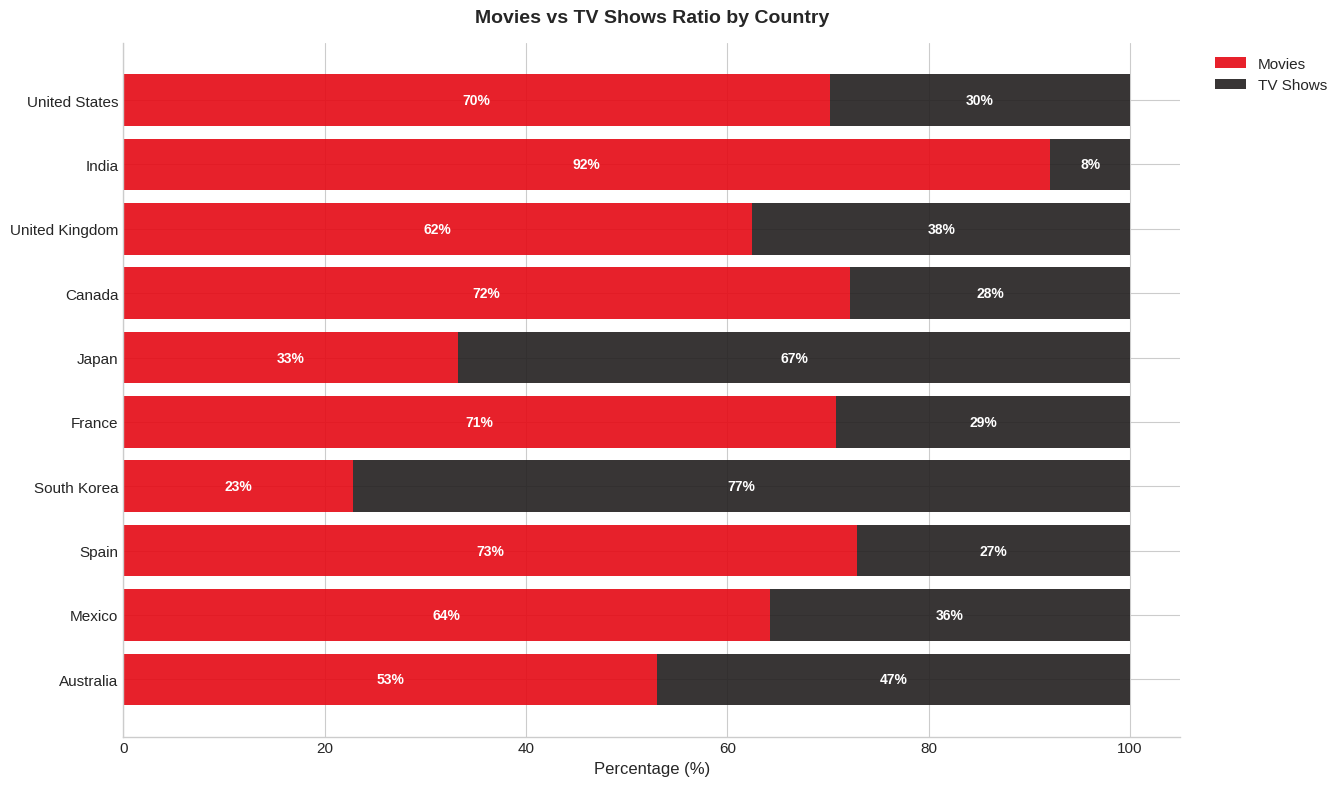

In [ ]:
fig, ax = plt.subplots(figsize=(16, 8))

countries = content_by_country.index
movie_pct = content_by_country['Movie_Pct']
tv_pct = content_by_country['TV_Show_Pct']

ax.barh(countries[::-1], movie_pct[::-1], color=NETFLIX_RED, label='Movies', alpha=0.9)
ax.barh(countries[::-1], tv_pct[::-1], left=movie_pct[::-1], color=NETFLIX_BLACK, label='TV Shows', alpha=0.9)

for i, country in enumerate(countries[::-1]):
    m_pct = movie_pct[country]
    t_pct = tv_pct[country]
    ax.text(m_pct/2, i, f'{m_pct:.0f}%', ha='center', va='center',
            color='white', fontweight='bold', fontsize=10)
    ax.text(m_pct + t_pct/2, i, f'{t_pct:.0f}%', ha='center', va='center',
            color='white', fontweight='bold', fontsize=10)

ax.set_title('Movies vs TV Shows Ratio by Country', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Percentage (%)')
ax.set_xlim(0, 105)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0))

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

**Observation:**
- **India** has the highest Movie percentage (~88%) - Bollywood's movie-centric industry.
- **South Korea** and **Japan** have higher TV Show percentages - K-Drama and Anime popularity.
- **Spain** shows strong TV Show content - Spanish language series gaining global popularity.
- This reflects regional entertainment industry structures and viewer preferences.

### 2.3 Top Genres by Region

In [ ]:
# Extract all genres and count
all_genres = []
for genres in df['listed_in'].dropna():
    all_genres.extend([g.strip() for g in genres.split(',')])

genre_counts = pd.Series(all_genres).value_counts().head(15)

genre_df = pd.DataFrame({
    'Genre': genre_counts.index,
    'Count': genre_counts.values
})
genre_df

,Genre,Count
0,International Movies,2752
1,Dramas,2427
2,Comedies,1674
3,International TV Shows,1328
4,Documentaries,869
5,Action & Adventure,859
6,Independent Movies,756
7,TV Dramas,739
8,Children & Family Movies,641
9,Romantic Movies,616


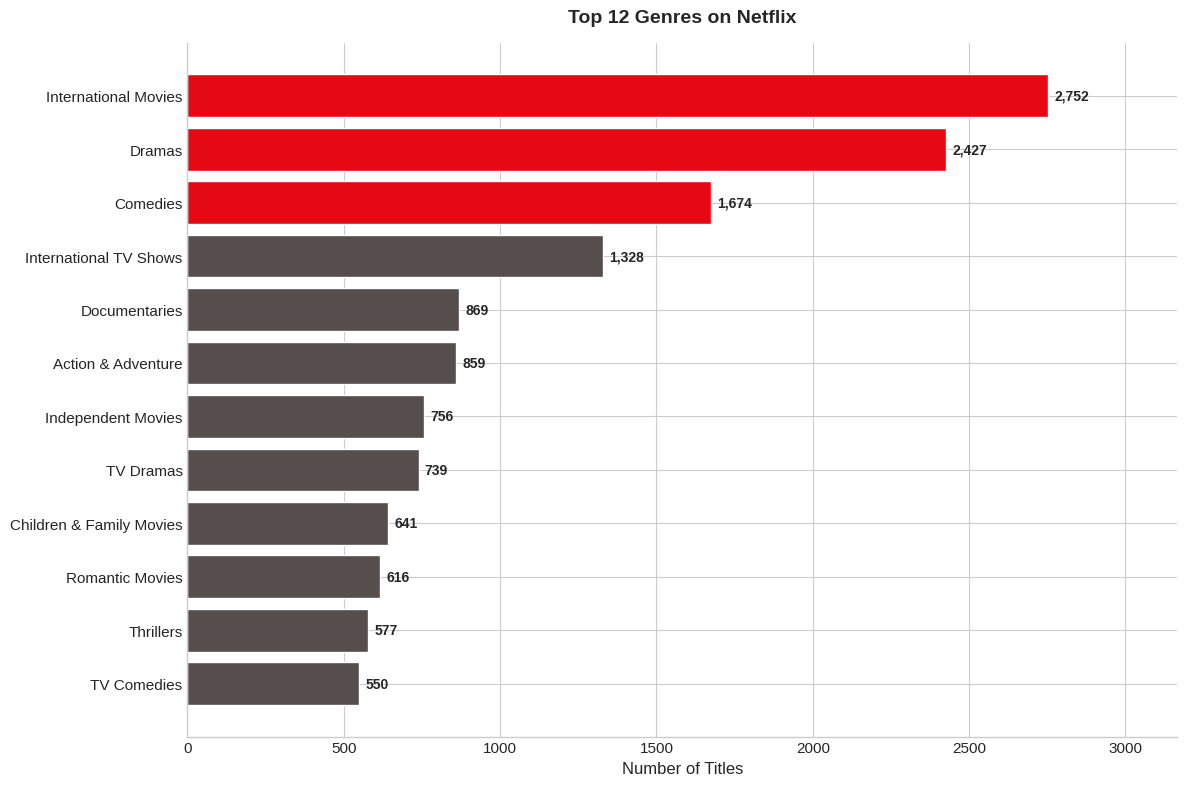

In [ ]:
# Visualization: Top Genres
fig, ax = plt.subplots(figsize=(12, 8))

top_genres = genre_counts.head(12)
colors = [NETFLIX_RED if i < 3 else NETFLIX_GREY for i in range(len(top_genres))]

bars = ax.barh(top_genres.index[::-1], top_genres.values[::-1], color=colors[::-1], edgecolor='white')

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + 20, bar.get_y() + bar.get_height()/2,
            f'{int(width):,}', ha='left', va='center', fontweight='bold', fontsize=10)

ax.set_title('Top 12 Genres on Netflix', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Titles')
ax.set_xlim(0, top_genres.max() * 1.15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Observation:**
- **International Movies** and **Dramas** dominate Netflix's catalog.
- Strong presence of **Comedies**, **Documentaries**, and **Action & Adventure**.
- "International" categories highlight Netflix's global content strategy.
- **Kids' TV** and **Children & Family Movies** show family-friendly content investment.

### 2.4 Genre Preferences: USA vs India vs South Korea

In [ ]:
# Compare genres across key markets
def get_top_genres(country, n=5):
    country_df = df[df['primary_country'] == country]
    genres = []
    for g in country_df['listed_in'].dropna():
        genres.extend([x.strip() for x in g.split(',')])
    return pd.Series(genres).value_counts().head(n)

countries_compare = ['United States', 'India', 'South Korea']

for country in countries_compare:
    print(f"\n{country} - Top 5 Genres:")
    print(get_top_genres(country))


United States - Top 5 Genres:
Dramas                      784
Comedies                    704
Documentaries               528
Children & Family Movies    443
Action & Adventure          365
Name: count, dtype: int64

India - Top 5 Genres:
International Movies    845
Dramas                  645
Comedies                315
Independent Movies      162
Action & Adventure      130
Name: count, dtype: int64

South Korea - Top 5 Genres:
International TV Shows    148
Korean TV Shows           127
Romantic TV Shows          76
International Movies       41
TV Dramas                  36
Name: count, dtype: int64


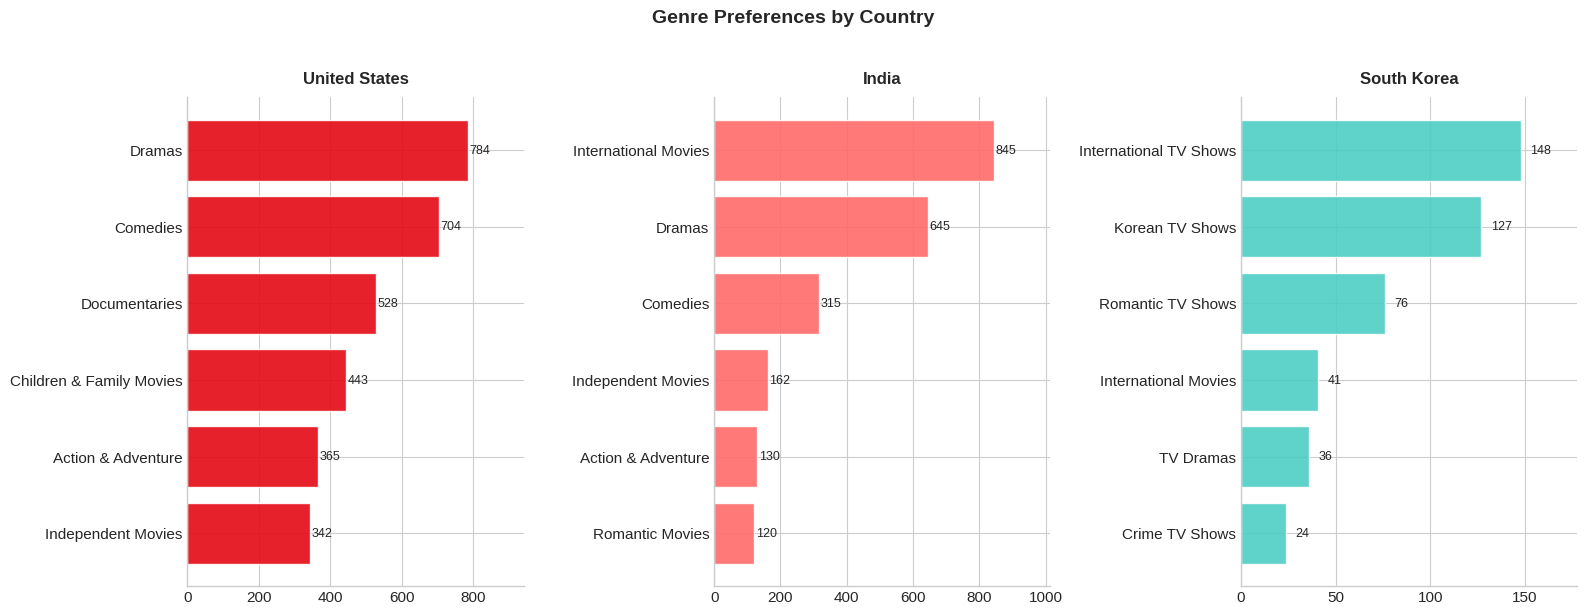

In [ ]:
# Visualization: Genre Comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

colors_list = [NETFLIX_RED, '#FF6B6B', '#4ECDC4']

for idx, country in enumerate(countries_compare):
    top_genres = get_top_genres(country, 6)

    bars = axes[idx].barh(top_genres.index[::-1], top_genres.values[::-1],
                          color=colors_list[idx], edgecolor='white', alpha=0.9)

    # Add value labels
    for bar in bars:
        width = bar.get_width()
        axes[idx].text(width + 5, bar.get_y() + bar.get_height()/2,
                       f'{int(width)}', ha='left', va='center', fontsize=9)

    axes[idx].set_title(country, fontsize=12, fontweight='bold', pad=10)
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)
    axes[idx].set_xlim(0, top_genres.max() * 1.2)

fig.suptitle('Genre Preferences by Country', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observation:**
- **USA**: Balanced mix with strong Documentaries, Stand-Up Comedy, and Dramas.
- **India**: Heavy focus on International Movies and Dramas - reflecting Bollywood influence.
- **South Korea**: Dominated by Korean TV Shows and Romantic content - K-Drama phenomenon.
- Each market has **distinct preferences** that Netflix caters to with localized content.

### 2.5 Content Ratings by Country

In [ ]:
# Rating distribution by top countries
rating_by_country = df[df['primary_country'].isin(top_10_countries[:6])].groupby(
    ['primary_country', 'rating']).size().unstack(fill_value=0)

# Focus on key ratings
key_ratings = ['TV-MA', 'TV-14', 'TV-PG', 'R', 'PG-13']
rating_by_country = rating_by_country[[r for r in key_ratings if r in rating_by_country.columns]]

rating_by_country

rating,TV-MA,TV-14,TV-PG,R,PG-13
primary_country,,,,,
Canada,84,34,25,37,7
France,114,31,4,15,8
India,260,562,139,2,5
Japan,90,92,42,0,4
United Kingdom,216,84,84,94,51
United States,1255,653,351,547,370


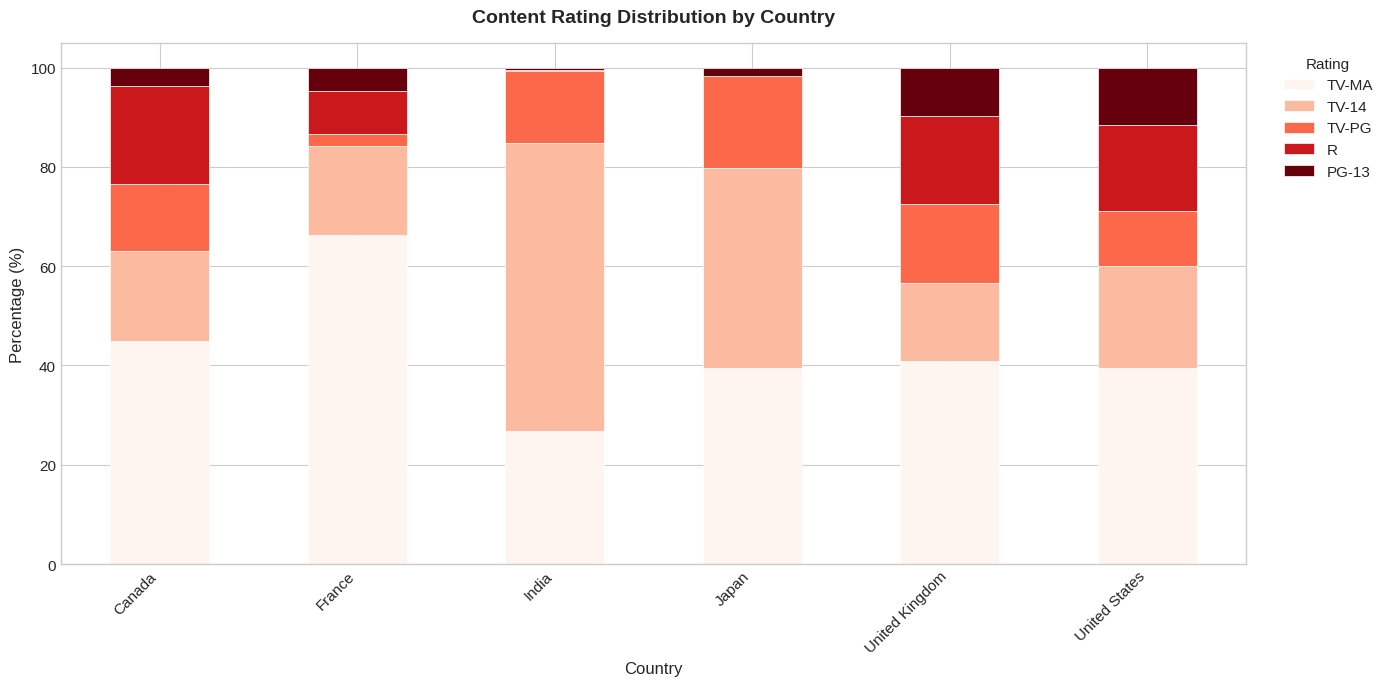

In [ ]:
# Visualization: Rating Distribution by Country
fig, ax = plt.subplots(figsize=(14, 7))

rating_by_country_pct = rating_by_country.div(rating_by_country.sum(axis=1), axis=0) * 100

rating_by_country_pct.plot(kind='bar', stacked=True, ax=ax,
                            colormap='Reds', edgecolor='white', linewidth=0.5)

ax.set_title('Content Rating Distribution by Country', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Country')
ax.set_ylabel('Percentage (%)')
ax.legend(title='Rating', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Observation:**
- **USA** and **UK** have higher mature content (TV-MA, R) - liberal content policies.
- **India** shows more family-friendly ratings - cultural preferences.
- **South Korea** balances between teen (TV-14) and mature content.
- Netflix tailors content ratings to match regional audience expectations.

### Question 2 Summary

| Finding | Insight |
|---------|--------|
| Country Distribution | USA dominates (40%), India second largest market |
| Content Type by Country | India: Movies (88%), South Korea: TV Shows (higher %), reflects local industry |
| Genre Preferences | Each market has distinct preferences (USA: Documentaries, India: Dramas, SK: K-Drama) |
| Ratings | Regional variation in content maturity ratings |

---

## Conclusions

### Key Findings

**Question 1 - Temporal Strategy:**
1. Netflix experienced explosive growth from 2016 following global expansion
2. Content mix shifting towards more TV Shows (20% → 35%)
3. Strategic release timing aligned with holiday seasons (July, December)
4. Trend towards adding fresher content (more originals)

**Question 2 - Geographic Intelligence:**
1. USA dominates content production (~40%), followed by India
2. Regional content type preferences vary significantly (India: Movies, Korea: TV Shows)
3. Genre preferences differ by market (USA: Documentaries, Korea: K-Drama)
4. Content ratings tailored to regional cultural norms

### Strategic Implications

Netflix's data reveals a sophisticated **localization strategy** that:
- Adapts content mix to regional preferences
- Times releases for maximum engagement
- Invests in original content to reduce licensing dependency
- Targets specific demographics through content ratings and genres

---

**Dataset Source:** [Kaggle - Netflix Movies and TV Shows](https://www.kaggle.com/datasets/shivamb/netflix-shows)